<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/32PipeLinePracticeWithMedian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [4]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


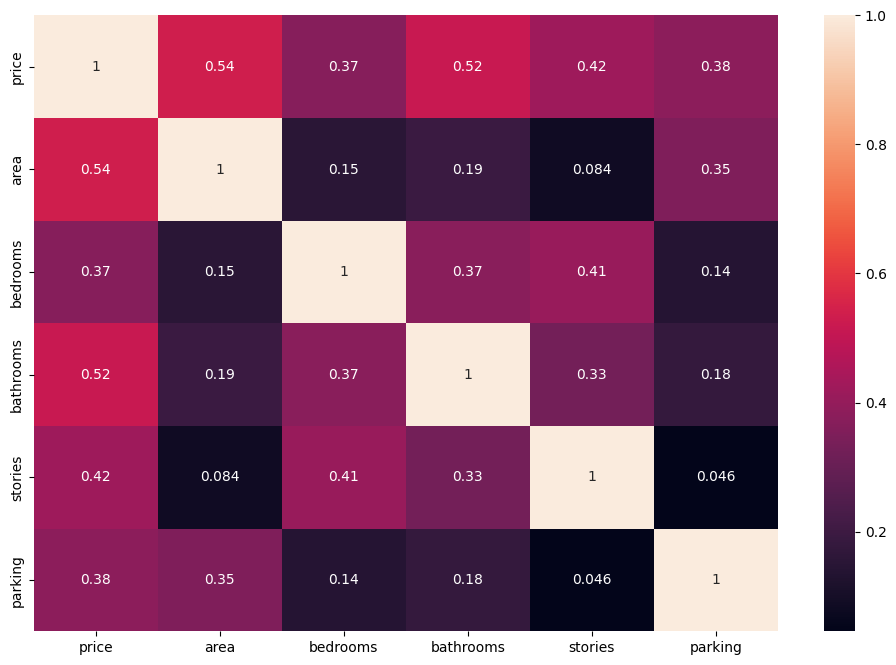

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

Area most correlates with price

<Axes: xlabel='stories', ylabel='price'>

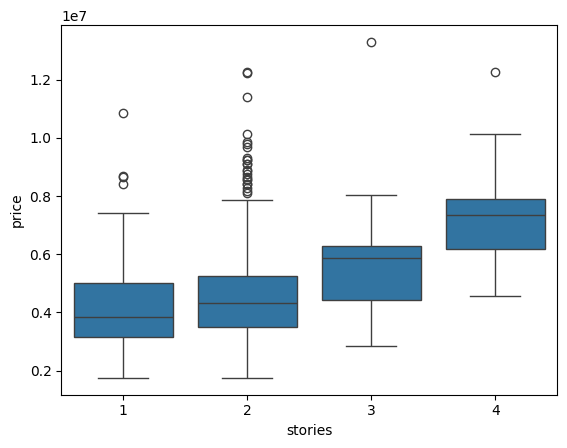

In [7]:
sns.boxplot(data = df, x ='stories', y = 'price' )

<Axes: xlabel='price', ylabel='Count'>

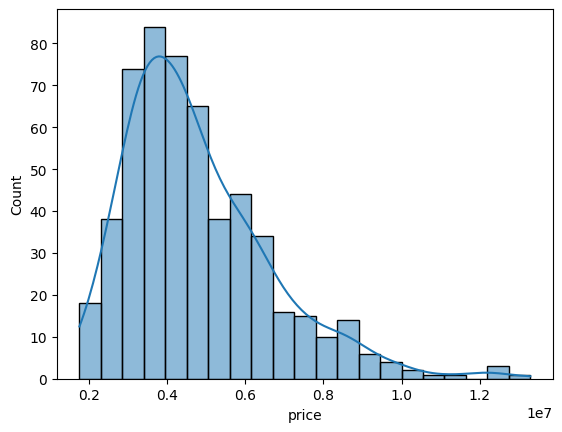

In [8]:
sns.histplot(data = df, x = 'price', kde=True)

Yes. it is right skewed

In [9]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [10]:
X = df.drop('price', axis=1)
y = df['price']

In [11]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [12]:
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
numeric_feature = X_train.select_dtypes(
    include = ["int64","float64"]
).columns

In [15]:
numeric_feature

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [16]:
categorical_features = X_train.select_dtypes(
    include = ["object"]
).columns

In [17]:
categorical_features

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [19]:
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [20]:
preprocessor = ColumnTransformer(transformers = [
    ('num', numeric_pipeline, numeric_feature)
])

In [21]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [22]:
X_train.shape

(436, 5)

In [23]:
X_test.shape

(109, 5)

In [24]:
lr_pipeline = Pipeline(steps=[
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', LinearRegression())])

In [25]:
print(f'Coefficient: {lr_pipeline.named_steps["model"].coef_}')
print(f'Intercept: {lr_pipeline.named_steps["model"].intercept_}')

Coefficient: [680058.42414123 112973.18562909 565408.61793601 424354.81176353
 288348.7726677 ]
Intercept: 4706527.385321101


In [26]:
ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001

In [27]:
sgd_pipeline = Pipeline(
    steps = [
        ("model",SGDRegressor(
            loss = "squared_error",
            penalty = 'l2',
            alpha = ALPHA,
            learning_rate = 'constant',
            eta0= ETA,
            max_iter = MAX_ITER,
            random_state = 42

        ))
    ]
)

sgd_pipeline.fit(X_train,y_train)

Pipeline(steps=[('model',
                 SGDRegressor(eta0=0.001, learning_rate='constant',
                              max_iter=3000, random_state=42))])

In [28]:
print(f'Coefficient: {sgd_pipeline.named_steps["model"].coef_}')
print(f'Intercept: {sgd_pipeline.named_steps["model"].intercept_}')

Coefficient: [674544.50244428 112851.3170461  561078.06141725 421790.26113856
 285271.51364252]
Intercept: [4702279.35575324]


Lr prediction

In [29]:
lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

print(lr_train_pred)
print(lr_test_pred)

[ 7048468.97357092  6609128.69348733  3889283.61945779  3487815.92311087
  3839924.25305077  4229096.6177212   3870810.94865954  3754381.07416122
  3168769.32541906  4045951.48070795  3645338.07071556  4413601.21630566
  5361623.58856861  3784328.200955    3457027.28535552  5364495.98552683
  2927853.0996707   5160545.73665557  4479600.687055    8428174.7917489
  6627660.71085259  3608274.03598504  4782882.1020396   5951477.2594548
  7210624.12551693  3809037.55744201  3158057.03980941  3422040.22941092
  5317167.02673169  3777335.28676513  3768884.85315062  2602405.38580775
  3654604.07939819  4773698.30859817  4176954.38149013  4874808.82903897
  3249172.79185527  6187991.56980421  5818347.07066178  6704018.72629249
  7342129.3268503   5572848.14979704  4522520.22600445  3571210.00125453
  4494820.25780998  4094191.00520537  7000265.44858155  6713963.18546251
  3047384.61167662  7534385.94279125  4584995.29182445  3694388.57016649
  7241808.28269704  6136797.43310739  5670090.9317397

In [30]:
sgd_train_pred = sgd_pipeline.predict(X_train)
sgd_test_pred = sgd_pipeline.predict(X_test)

print(sgd_train_pred)
print(sgd_test_pred)

[ 7027662.01746442  6587085.83865617  3888563.6905554   3494167.95793869
  3843421.38940045  4229438.33996344  3874057.65531815  3757549.61030481
  3176686.00850525  4046755.96056788  3650412.91411895  4410361.63312647
  5349163.30506979  3788276.11074859  3462565.80015898  5355141.90576496
  2937723.13434721  5153908.44257016  4476889.13405236  8394334.18921849
  6605467.59820678  3613649.39501771  4779755.91037139  5936122.38024572
  7188502.41353234  3812785.12348275  3164997.42357205  3427903.38903038
  5305402.01710113  3779254.55522189  3772957.97778974  2613850.99971266
  3659603.79389426  4768758.63444818  4177875.29942187  4866964.00963342
  3255374.40802926  6172117.00399012  5804603.82731099  6684491.14616632
  7317960.15319651  5559343.6193734   4520482.86618157  3576885.87591648
  4491944.33499364  4094760.78425882  6979514.50767999  6694021.43078625
  3056285.4834487   7508773.40670553  4584775.08793625  3695248.85261472
  7218118.96849026  6119939.97575191  5657549.75090

In [31]:
from sklearn.metrics import root_mean_squared_error

In [32]:
lr_metrics = {
    "Model": "Linear Regression",
    "Train RMSE": root_mean_squared_error(y_train, lr_train_pred),
    "Test RMSE": root_mean_squared_error(y_test, lr_test_pred),
    "Train MAE": mean_absolute_error(y_train, lr_train_pred),
    "Test MAE": mean_absolute_error(y_test, lr_test_pred),
    "Train R²": r2_score(y_train, lr_train_pred),
    "Test R²": r2_score(y_test, lr_test_pred)
}

In [33]:
sgd_metrics = {
    "Model": "SGD Regressor",
    "Train RMSE": root_mean_squared_error(y_train, sgd_train_pred),
    "Test RMSE": root_mean_squared_error(y_test, sgd_test_pred),
    "Train MAE": mean_absolute_error(y_train, sgd_train_pred),
    "Test MAE": mean_absolute_error(y_test, sgd_test_pred),
    "Train R²": r2_score(y_train, sgd_train_pred),
    "Test R²": r2_score(y_test, sgd_test_pred)
}

In [34]:
results_df = pd.DataFrame([lr_metrics, sgd_metrics])
results_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²
0,Linear Regression,1.161899e+06,1.514174e+06,853544.161516,1.127483e+06,0.562168,0.546406
1,SGD Regressor,1.161950e+06,1.516719e+06,852981.030334,1.128789e+06,0.562129,0.544880


In [35]:
lr_RMSE = root_mean_squared_error(y_test, lr_test_pred)
sgd_RMSE = root_mean_squared_error(y_test, sgd_test_pred)

print(f'Linear regression rmse: {lr_RMSE}')
print(f'SGD regressor rmse: {sgd_RMSE}')

Linear regression rmse: 1514173.552049225
SGD regressor rmse: 1516719.4617952663


SGD test has bigger RMSE

Lr data

In [36]:
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

print(lr_train_r2)
print(lr_test_r2)

0.5621678833074251
0.5464062355495862


SGD data

In [37]:
sgd_train_r2 = r2_score(y_train, sgd_train_pred)
sgd_test_r2 = r2_score(y_test, sgd_test_pred)

print(sgd_train_r2)
print(sgd_test_r2)

0.5621289046887372
0.5448796210824686
